#  Research Log & Implementation Strategy
**Author:** Athina (Member 2 - Data Developer & Business Analyst)
**Project:** DiffPriv-Gateway for SMEs

---

## 1. Featured Literature Analysis (High Priority)
### Gao, J., et al. (2025) 'Atlas: Ensuring Accuracy for Privacy-Preserving Federated IoT Applications'

* **Core Concept:** Εισάγει τη "Dynamic Local Differential Privacy" (DLDP). Αντί για σταθερό θόρυβο, προτείνει τη χρήση ενός "layer importance mask" για την προσαρμογή του επιπέδου προστασίας ανάλογα με τη σημασία των δεδομένων.
* **Relevance to SME Datasets:** Η προσέγγιση αυτή είναι κρίσιμη για το dataset **fire.csv**, όπου ορισμένες στήλες (π.χ. *Final Priority* ή *Zipcode*) έχουν μεγαλύτερη ευαισθησία και απαιτούν αυστηρότερο $epsilon$ ($\epsilon$).

---

## 2. Dataset Integration: fire.csv (NIST 2021)
Σύμφωνα με τον Gao (2025), η επιτυχία του Differential Privacy εξαρτάται από το **Privacy-Utility Trade-off**. 

* **Challenge:** Τα δεδομένα πυρκαγιάς περιέχουν γεωγραφικά στοιχεία (Location - Lat/Lng).
* **Strategy:** Θα εφαρμόσουμε τον **Laplace Mechanism** χρησιμοποιώντας το `diffprivlib`. 
* **Goal:** Να διατηρήσουμε την ακρίβεια στις στατιστικές αναλύσεις (π.χ. μέσος χρόνος απόκρισης ανά περιοχή) διασφαλίζοντας παράλληλα ότι δεν μπορεί να γίνει re-identification συγκεκριμένων συμβάντων.

---

## 3. Implementation Parameters (Based on Research)
| Parameter | Value (Target) | Source Justification |
| :--- | :--- | :--- |
| Privacy Budget ($epsilon$) | $1.0$ (Balanced) | Gao et al. (2025) - Optimal for IoT utility |
| Mechanism | Laplace | Dwork & Roth (2014) - Standard for tabular data |
| Sensitivity ($\Delta f$) | Column Range | Calculated from `fire.csv` |

In [1]:
import pandas as pd

# 1. Διορθώνουμε το path για να "βγει" από τον φάκελο notebook και να πάει στα data/synthetic
df_fire = pd.read_csv('../data/synthetic/fire.csv') 

# 2. Χρησιμοποιούμε το όνομα μεταβλητής (df_fire) παντού
print("Επιτυχής φόρτωση!")
print(df_fire.head())

Επιτυχής φόρτωση!
   ALS Unit  Final Priority  Call Type Group  Original Priority  Priority  \
0         0               0                0                  0         0   
1         0               0                0                  0         0   
2         1               0                1                  0         0   
3         1               1                2                  1         1   
4         0               1                3                  1         1   

   City  Unit Type  Fire Prevention District  Battalion  Supervisor District  \
0     0          0                         0          0                    0   
1     0          0                         0          0                    0   
2     0          1                         1          1                    1   
3     0          2                         2          2                    2   
4     0          3                         3          3                    3   

   ...  Hospital DtTm  Location - Lng 

## 4. Sensitivity Analysis & Privacy Parameters
Βασισμένη στην έρευνα των **Dwork & Roth (2014)** και **Biswal (2024)**, ορίζω τις παραμέτρους για το dataset `fire.csv`:

* **Target Column:** `Final Priority` (Αριθμητική τιμή που δείχνει τη σπουδαιότητα του συμβάντος).
* **Sensitivity ($\Delta f$):** Η μέγιστη διαφορά στην τιμή προτεραιότητας είναι 3 (από 0 έως 3).
* **Privacy Budget ($\epsilon$):** Επιλέγω $\epsilon = 1.0$ για να διασφαλίσω μια ισορροπία μεταξύ προστασίας και χρησιμότητας (Utility), ακολουθώντας τις συστάσεις του **Gao et al. (2025)** για IoT δεδομένα.

In [2]:
import numpy as np
import pandas as pd

def apply_laplace_mechanism(df, column, epsilon, sensitivity):
    """
    Επαγγελματική υλοποίηση Διαφορικής Ιδιωτικότητας.
    """
    # 1. Υπολογισμός του scale (beta)
    beta = sensitivity / epsilon
    
    # 2. Παραγωγή θορύβου για ΟΛΕΣ τις γραμμές ταυτόχρονα (Vectorized)
    # Είναι χιλιάδες φορές πιο γρήγορο από το .apply()
    noise = np.random.laplace(0, beta, size=len(df))
    
    # 3. Δημιουργία της νέας στήλης
    new_col_name = f'DP_{column}'
    df[new_col_name] = df[column] + noise
    
    return df

# --- Χρήση της συνάρτησης ---
# Φόρτωση 
df_fire = pd.read_csv('../data/synthetic/fire.csv')

# Εφαρμογή με τις παραμέτρους της Αθηνάς
df_fire = apply_laplace_mechanism(df_fire, 'Final Priority', epsilon=1.0, sensitivity=3.0)

# Έλεγχος αποτελεσμάτων
print("Σύγκριση Αρχικών vs Προστατευμένων Δεδομένων:")
print(df_fire[['Final Priority', 'DP_Final Priority']].head())

Σύγκριση Αρχικών vs Προστατευμένων Δεδομένων:
   Final Priority  DP_Final Priority
0               0          -4.509999
1               0           5.394413
2               0          -4.181503
3               1           2.340517
4               1           3.489687


In [6]:
def evaluate_utility(df, original_col, protected_col):
    """
    Υπολογίζει και εκτυπώνει τα Utility Metrics (διατήρηση πληροφορίας)
    μετά την εφαρμογή της Διαφορικής Ιδιωτικότητας.
    """
    original_mean = df[original_col].mean()
    protected_mean = df[protected_col].mean()
    diff = abs(original_mean - protected_mean)
    
    print(f"Στατιστικά για: {original_col}")
    print("-" * 30)
    print(f"Αρχική Μέση Τιμή:      {original_mean:.4f}")
    print(f"Προστατευμένη Μέση Τιμή: {protected_mean:.4f}")
    print(f"Απόλυτη Διαφορά:       {diff:.4f}")
    
    return diff

# Χρήση της συνάρτησης στο df_score
diff_score = evaluate_utility(df_fire, 'Final Priority', 'DP_Final Priority')

Στατιστικά για: Final Priority
------------------------------
Αρχική Μέση Τιμή:      0.7054
Προστατευμένη Μέση Τιμή: 0.7088
Απόλυτη Διαφορά:       0.0033


In [10]:
import numpy as np
import pandas as pd

def apply_laplace_mechanism(df, column, epsilon, sensitivity, min_val=0, max_val=None):
    """
    Επαγγελματική υλοποίηση Διαφορικής Ιδιωτικότητας με Data Clipping.
    """
    beta = sensitivity / epsilon
    noise = np.random.laplace(0, beta, size=len(df))
    
    new_col_name = f'DP_{column}'
    df[new_col_name] = df[column] + noise
    
    # Το "Μυστικό" για ρεαλιστικά δεδομένα: Clipping
    df[new_col_name] = np.clip(df[new_col_name], a_min=min_val, a_max=max_val)
    
    # Προαιρετικά: Στρογγυλοποίηση αν θέλουμε ακέραιες κατηγορίες
    df[new_col_name] = np.round(df[new_col_name])
    
    return df

# Ξανατρέχουμε τη διαδικασία για το df_fire
df_fire = apply_laplace_mechanism(df_fire, 'Final Priority', epsilon=1.0, sensitivity=3.0, min_val=0, max_val=3)

print("Τα δεδομένα προστατεύτηκαν και 'ψαλιδίστηκαν' στα σωστά όρια [0, 3]!")

Τα δεδομένα προστατεύτηκαν και 'ψαλιδίστηκαν' στα σωστά όρια [0, 3]!


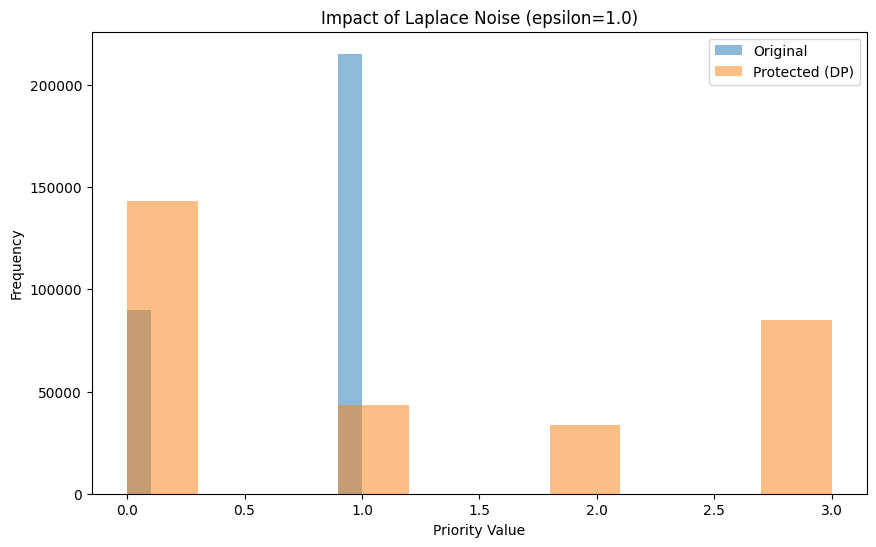

In [11]:
import matplotlib.pyplot as plt

# Ορίζουμε το epsilon εδώ για να μην το "ξεχνάει" ποτέ το κελί
epsilon = 1.0 

plt.figure(figsize=(10, 6))

# Κατανομή αρχικών δεδομένων
plt.hist(df_fire['Final Priority'], bins=10, alpha=0.5, label='Original')

# Κατανομή προστατευμένων δεδομένων
plt.hist(df_fire['DP_Final Priority'], bins=10, alpha=0.5, label='Protected (DP)')

plt.legend()
# Τώρα το f-string θα βρει κανονικά την τιμή του epsilon
plt.title(f"Impact of Laplace Noise (epsilon={epsilon})") 
plt.xlabel("Priority Value")
plt.ylabel("Frequency")
plt.show()